# Modelo de ClasificaciÃ³n de Niveles de Ansiedad
**Dataset:** DASS-42 (Depression Anxiety Stress Scales)  
**Modelo:** Random Forest  
**Clases:** Leve Â· Moderado Â· Severo

## 1. Imports y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('data.csv', sep='\t', low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (39775, 172)


,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,...,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,8,2044,4,34,2153,4,33,2416,4,10,2818,4,13,2259,2,...,1,0,0,1,0,0,0,1,1,1,2,3,2,2,16,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,28,3090,4,10,5078,4,40,2790,3,18,3408,4,1,8342,3,...,0,0,0,1,0,0,0,1,1,1,2,3,2,1,16,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,13,6470,4,11,3927,3,9,3704,1,17,4550,3,5,3021,2,...,0,0,0,0,1,0,0,1,1,1,2,3,2,2,17,2,1,1,4,3,60,1,1,3,NaN


## 2. CÃ¡lculo del score de ansiedad (DASS-42)

El cuestionario DASS-42 mide ansiedad con **14 Ã­tems** especÃ­ficos:
- Items: Q2, Q4, Q7, Q9, Q15, Q19, Q20, Q23, Q25, Q28, Q30, Q36, Q40, Q41
- Escala original: 0â€“3 por Ã­tem (el dataset usa 1â€“4, restamos 1)
- Score mÃ¡ximo: 42

| Nivel   | Score DASS-42 |
|---------|---------------|
| Normal  | 0 â€“ 7         |
| Leve    | 8 â€“ 9         |
| Moderado| 10 â€“ 14       |
| Severo  | 15 â€“ 19       |
| Extremo | 20+           |

In [2]:
# Items de ansiedad del DASS-42
ANXIETY_ITEMS = [2, 4, 7, 9, 15, 19, 20, 23, 25, 28, 30, 36, 40, 41]
anxiety_cols = [f'Q{i}A' for i in ANXIETY_ITEMS]

# El dataset usa escala 1-4, convertimos a 0-3
df_clean = df.copy()
for col in anxiety_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Score de ansiedad (suma de los 14 Ã­tems, escala 0-3)
df_clean['anxiety_score'] = df_clean[anxiety_cols].sub(1).clip(lower=0).sum(axis=1)

# ClasificaciÃ³n en niveles
def classify_anxiety(score):
    if score <= 9:      return 'Leve'       # normal + leve
    elif score <= 14:   return 'Moderado'
    else:               return 'Severo'      # severo + extremadamente severo

df_clean['anxiety_level'] = df_clean['anxiety_score'].apply(classify_anxiety)

print('DistribuciÃ³n de niveles de ansiedad:')
print(df_clean['anxiety_level'].value_counts())
print(f'\nTotal registros vÃ¡lidos: {df_clean["anxiety_score"].notna().sum()}')

DistribuciÃ³n de niveles de ansiedad:
anxiety_level
Severo      20235
Leve        12492
Moderado     7048
Name: count, dtype: int64

Total registros vÃ¡lidos: 39775


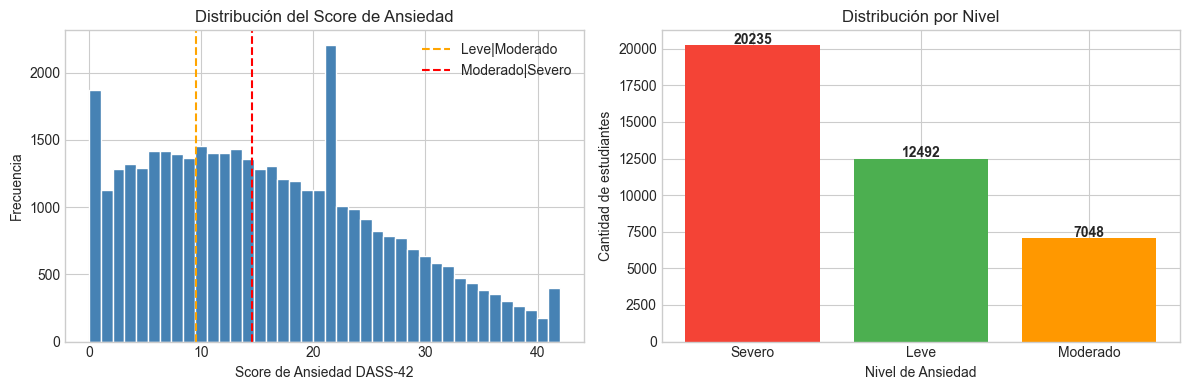

In [3]:
# VisualizaciÃ³n de la distribuciÃ³n
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma del score
axes[0].hist(df_clean['anxiety_score'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(9.5, color='orange', linestyle='--', label='Leve|Moderado')
axes[0].axvline(14.5, color='red', linestyle='--', label='Moderado|Severo')
axes[0].set_xlabel('Score de Ansiedad DASS-42')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('DistribuciÃ³n del Score de Ansiedad')
axes[0].legend()

# Barras por nivel
counts = df_clean['anxiety_level'].value_counts()
colors = {'Leve': '#4CAF50', 'Moderado': '#FF9800', 'Severo': '#F44336'}
axes[1].bar(counts.index, counts.values, color=[colors[l] for l in counts.index])
axes[1].set_xlabel('Nivel de Ansiedad')
axes[1].set_ylabel('Cantidad de estudiantes')
axes[1].set_title('DistribuciÃ³n por Nivel')
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 100, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_ansiedad.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. PreparaciÃ³n de features

In [4]:
# Features: todas las respuestas QXA + personalidad TIPI + demografÃ­a
all_q_cols = [f'Q{i}A' for i in range(1, 43) if i not in ANXIETY_ITEMS]  # Ã­tems no-ansiedad
tipi_cols  = [f'TIPI{i}' for i in range(1, 11)]  # Big Five personality
demo_cols  = ['age', 'gender', 'education', 'urban', 'religion', 'orientation', 
              'race', 'married', 'familysize']

feature_cols = all_q_cols + tipi_cols + demo_cols

# Convertir todo a numÃ©rico
for col in feature_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Filtrar columnas existentes
feature_cols = [c for c in feature_cols if c in df_clean.columns]

# Dataset final (solo filas con target vÃ¡lido)
df_model = df_clean[feature_cols + ['anxiety_level']].dropna(subset=['anxiety_level'])

print(f'Features usadas: {len(feature_cols)}')
print(f'Registros para entrenamiento: {len(df_model)}')
df_model[feature_cols].isnull().sum()[df_model[feature_cols].isnull().sum() > 0].head(10)

Features usadas: 47
Registros para entrenamiento: 39775


Series([], dtype: int64)

In [5]:
X = df_model[feature_cols]
y = df_model['anxiety_level']

# Encode target
le = LabelEncoder()
le.fit(['Leve', 'Moderado', 'Severo'])
y_enc = le.transform(y)

print('Clases:', le.classes_)
print('DistribuciÃ³n:', dict(zip(le.classes_, np.bincount(y_enc))))

Clases: ['Leve' 'Moderado' 'Severo']
DistribuciÃ³n: {np.str_('Leve'): np.int64(12492), np.str_('Moderado'): np.int64(7048), np.str_('Severo'): np.int64(20235)}


## 4. Entrenamiento del Random Forest

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 31820 | Test: 7955


In [7]:
# Pipeline: imputaciÃ³n de NaN + Random Forest
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',   # maneja desbalance
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)
print('Modelo entrenado âœ“')

Modelo entrenado âœ“


## 5. EvaluaciÃ³n

In [8]:
y_pred = pipeline.predict(X_test)

print('='*55)
print('REPORTE DE CLASIFICACIÃ“N')
print('='*55)
print(classification_report(y_test, y_pred, target_names=le.classes_))

REPORTE DE CLASIFICACIÃ“N
              precision    recall  f1-score   support

        Leve       0.74      0.81      0.77      2498
    Moderado       0.41      0.21      0.28      1410
      Severo       0.80      0.90      0.85      4047

    accuracy                           0.75      7955
   macro avg       0.65      0.64      0.63      7955
weighted avg       0.71      0.75      0.72      7955



In [9]:
# ValidaciÃ³n cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y_enc, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'Cross-validation F1 Macro (5-fold):')
print(f'  Folds: {cv_scores.round(3)}')
print(f'  Media: {cv_scores.mean():.3f} Â± {cv_scores.std():.3f}')

Cross-validation F1 Macro (5-fold):
  Folds: [0.635 0.626 0.632 0.637 0.627]
  Media: 0.632 Â± 0.004


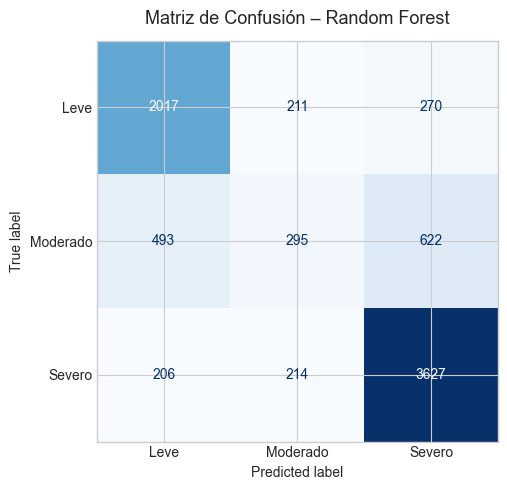

In [10]:
# Matriz de confusiÃ³n
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de ConfusiÃ³n â€“ Random Forest', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Importancia de features

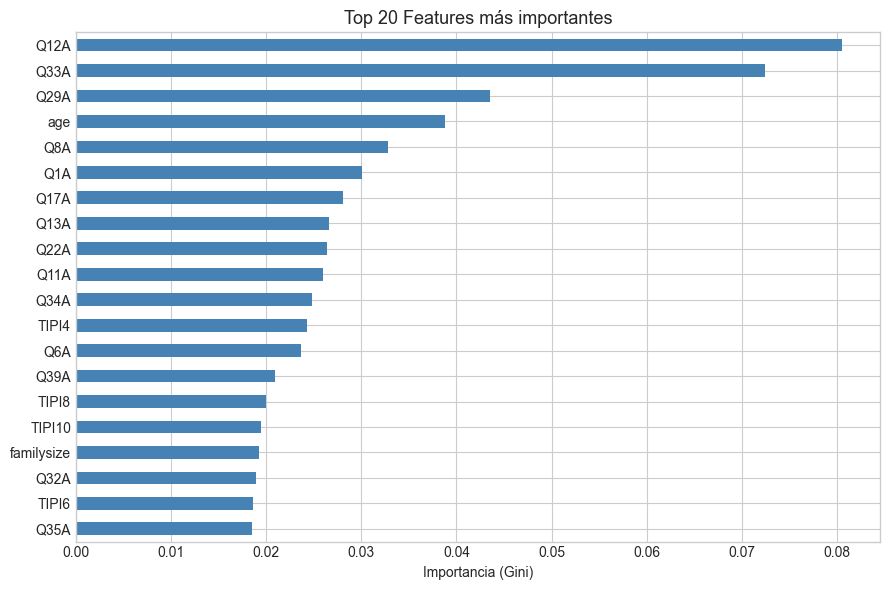


Top 10:
Q12A    0.0805
Q33A    0.0724
Q29A    0.0436
age     0.0388
Q8A     0.0328
Q1A     0.0300
Q17A    0.0281
Q13A    0.0266
Q22A    0.0264
Q11A    0.0259


In [11]:
rf_model = pipeline.named_steps['rf']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features mÃ¡s importantes', fontsize=13)
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10:')
print(top20.head(10).round(4).to_string())

## 7. FunciÃ³n de predicciÃ³n

In [12]:
def predecir_ansiedad(respuestas: dict) -> dict:
    """
    Predice el nivel de ansiedad dado un diccionario de respuestas.
    
    respuestas: {nombre_columna: valor}
    Ejemplo: {'Q1A': 3, 'Q3A': 2, 'age': 20, ...}
    """
    row = pd.DataFrame([respuestas])
    row = row.reindex(columns=feature_cols)  # alinear con las features del modelo
    
    pred_enc   = pipeline.predict(row)[0]
    pred_proba = pipeline.predict_proba(row)[0]
    
    nivel = le.classes_[pred_enc]
    proba = {le.classes_[i]: round(p * 100, 1) for i, p in enumerate(pred_proba)}
    
    return {'nivel': nivel, 'probabilidades': proba}

# Ejemplo de uso
ejemplo = {f'Q{i}A': 3 for i in range(1, 43) if i not in ANXIETY_ITEMS}
ejemplo.update({'age': 21, 'gender': 2, 'education': 3})
resultado = predecir_ansiedad(ejemplo)
print('PredicciÃ³n de ejemplo:')
print(f"  Nivel: {resultado['nivel']}")
print(f"  Probabilidades: {resultado['probabilidades']}")

PredicciÃ³n de ejemplo:
  Nivel: Severo
  Probabilidades: {np.str_('Leve'): np.float64(0.0), np.str_('Moderado'): np.float64(0.5), np.str_('Severo'): np.float64(99.5)}


## 8. Mejora del modelo – Severo

Estrategias:
1. **SMOTE** para balancear Moderado vs Severo
2. **RandomizedSearchCV** para hiperparámetros óptimos
3. **Ajuste de umbral** para maximizar F1 de Severo

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

# Imputar NaN antes de SMOTE
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# SMOTE: oversamplea Moderado para equilibrar clases
sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train_imp, y_train)

print("Distribución post-SMOTE:")
unique, counts = np.unique(y_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")


In [ ]:
# RandomizedSearchCV optimizando F1 de Severo
param_dist = {
    "n_estimators"     : [200, 300, 500],
    "max_depth"        : [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2", 0.4],
    "class_weight"     : ["balanced", "balanced_subsample",
                          {0: 1, 1: 3, 2: 1}]
}

severo_idx = list(le.classes_).index("Severo")
severo_f1  = make_scorer(f1_score, labels=[severo_idx], average="macro")

rf_search = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_search,
    param_distributions=param_dist,
    n_iter=30,
    scoring=severo_f1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_res, y_res)
print("\nMejores parámetros:")
print(search.best_params_)
print(f"Mejor F1-Severo CV: {search.best_score_:.4f}")


In [ ]:
# Evaluación v2: SMOTE + mejores hiperparámetros
best_rf    = search.best_estimator_
y_pred_v2  = best_rf.predict(X_test_imp)
y_proba_v2 = best_rf.predict_proba(X_test_imp)

print("="*55)
print("REPORTE v2 – SMOTE + HyperParam Tuning")
print("="*55)
print(classification_report(y_test, y_pred_v2, target_names=le.classes_))


In [ ]:
# Ajuste de umbral para Severo – maximizar F1
thresholds = np.arange(0.30, 0.75, 0.02)
f1_severo_list, precision_severo, recall_severo = [], [], []

for thr in thresholds:
    severo_mask = y_proba_v2[:, severo_idx] >= thr
    non_severo_proba = y_proba_v2.copy()
    non_severo_proba[:, severo_idx] = 0
    y_thr = np.argmax(y_proba_v2, axis=1)
    y_thr[severo_mask]  = severo_idx
    y_thr[~severo_mask] = np.argmax(non_severo_proba[~severo_mask], axis=1)

    f1_severo_list.append(f1_score(y_test, y_thr, labels=[severo_idx], average="macro"))
    precision_severo.append(precision_score(y_test, y_thr, labels=[severo_idx], average="macro", zero_division=0))
    recall_severo.append(recall_score(y_test, y_thr, labels=[severo_idx], average="macro", zero_division=0))

best_thr_idx = int(np.argmax(f1_severo_list))
best_thr = thresholds[best_thr_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_severo_list,  label="F1 Severo",    color="red",       linewidth=2)
ax.plot(thresholds, precision_severo, label="Precision",   color="steelblue", linestyle="--")
ax.plot(thresholds, recall_severo,   label="Recall",       color="green",     linestyle="--")
ax.axvline(best_thr, color="red", linestyle=":", alpha=0.7, label=f"Umbral óptimo = {best_thr:.2f}")
ax.set_xlabel("Umbral de probabilidad para Severo")
ax.set_ylabel("Score")
ax.set_title("Optimización de umbral – Clase Severo")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Umbral óptimo para Severo: {best_thr:.2f}")
print(f"  F1:        {f1_severo_list[best_thr_idx]:.4f}")
print(f"  Precision: {precision_severo[best_thr_idx]:.4f}")
print(f"  Recall:    {recall_severo[best_thr_idx]:.4f}")


In [ ]:
# Predicciones finales con umbral óptimo
severo_mask_final = y_proba_v2[:, severo_idx] >= best_thr
non_severo = y_proba_v2.copy()
non_severo[:, severo_idx] = 0
y_pred_final = np.argmax(y_proba_v2, axis=1)
y_pred_final[severo_mask_final]  = severo_idx
y_pred_final[~severo_mask_final] = np.argmax(non_severo[~severo_mask_final], axis=1)

print("="*55)
print("REPORTE FINAL – SMOTE + Tuning + Umbral óptimo")
print("="*55)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

# Comparativa F1 por versión
from sklearn.metrics import classification_report as cr
def get_f1s(y_true, y_pred_arg):
    rep = cr(y_true, y_pred_arg, target_names=le.classes_, output_dict=True)
    return [rep[c]["f1-score"] for c in le.classes_]

v1 = get_f1s(y_test, y_pred)
v2 = get_f1s(y_test, y_pred_v2)
v3 = get_f1s(y_test, y_pred_final)

x = np.arange(len(le.classes_))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, v1, width, label="v1 Baseline",       color="#90CAF9")
ax.bar(x,         v2, width, label="v2 SMOTE+Tuning",   color="#1565C0")
ax.bar(x + width, v3, width, label="v3 +Umbral óptimo", color="#F44336")
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, fontsize=12)
ax.set_ylabel("F1-Score")
ax.set_title("Comparativa F1 por clase y versión de modelo")
ax.legend()
ax.set_ylim(0, 1)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig("comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Matrices de confusión: baseline vs final
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_p, title) in zip(axes, [
    (y_pred,       "v1 Baseline"),
    (y_pred_final, "v3 Final (SMOTE + Tuning + Umbral)")
]):
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig("confusion_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
